# Financial Risk Analysis using Machine Learning

## Overview

Financial data can provide valuable insights into how healthy a company is and whether it may face financial difficulties in the future. Being able to identify these risks early is important for banks, investors and other financial institutions.

For this project, I analysed financial statement data from Taiwanese companies and used machine learning to predict the likelihood of bankruptcy. Along the way, I explored the data, compared different classification models and looked at which financial indicators were most useful for identifying companies that were at higher risk.

This project gave me the opportunity to apply machine learning to a real financial problem while developing a better understanding of financial risk analysis.

In [45]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

In [2]:
from google.colab import files

uploaded = files.upload()

Saving data.csv to data.csv


In [3]:
df = pd.read_csv("data.csv")
df.head()


,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


In [4]:
df.shape


(6819, 96)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   Bankrupt?                                                 6819 non-null   int64  
 1    ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2    ROA(A) before interest and % after tax                   6819 non-null   float64
 3    ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4    Operating Gross Margin                                   6819 non-null   float64
 5    Realized Sales Gross Margin                              6819 non-null   float64
 6    Operating Profit Rate                                    6819 non-null   float64
 7    Pre-tax net Interest Rate                                6819 non-null   float64
 8    After-tax net Int

In [6]:
df.columns = df.columns.str.strip()

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Bankrupt?,6819.0,0.032263,0.176710,0.0,0.000000,0.000000,0.000000,1.0
ROA(C) before interest and depreciation before interest,6819.0,0.505180,0.060686,0.0,0.476527,0.502706,0.535563,1.0
ROA(A) before interest and % after tax,6819.0,0.558625,0.065620,0.0,0.535543,0.559802,0.589157,1.0
ROA(B) before interest and depreciation after tax,6819.0,0.553589,0.061595,0.0,0.527277,0.552278,0.584105,1.0
Operating Gross Margin,6819.0,0.607948,0.016934,0.0,0.600445,0.605997,0.613914,1.0
...,...,...,...,...,...,...,...,...
Liability to Equity,6819.0,0.280365,0.014463,0.0,0.276944,0.278778,0.281449,1.0
Degree of Financial Leverage (DFL),6819.0,0.027541,0.015668,0.0,0.026791,0.026808,0.026913,1.0
Interest Coverage Ratio (Interest expense to EBIT),6819.0,0.565358,0.013214,0.0,0.565158,0.565252,0.565725,1.0
Net Income Flag,6819.0,1.000000,0.000000,1.0,1.000000,1.000000,1.000000,1.0


Initial Observations-

The dataset contains financial information for thousands of companies along with a binary target variable indicating whether a company eventually went bankrupt.

Before building a machine learning model, lets understand the structure of the dataset, identify missing values and explore the financial indicators available for analysis.

In [8]:
df.isnull().sum()

,0
Bankrupt?,0
ROA(C) before interest and depreciation before interest,0
ROA(A) before interest and % after tax,0
ROA(B) before interest and depreciation after tax,0
Operating Gross Margin,0
...,...
Liability to Equity,0
Degree of Financial Leverage (DFL),0
Interest Coverage Ratio (Interest expense to EBIT),0
Net Income Flag,0


In [9]:
df.isnull().sum().sum()

np.int64(0)

In [10]:
df.duplicated().sum()

np.int64(0)



I checked the dataset for missing values and duplicate records before beginning the analysis.

## Exploratory Data Analysis

Before building any machine learning models, it is important to understand the characteristics of the dataset and identify any patterns that may be linked to bankruptcy.

In this section, I explore the distribution of the target variable and examine how key financial indicators differ between bankrupt and non-bankrupt companies.

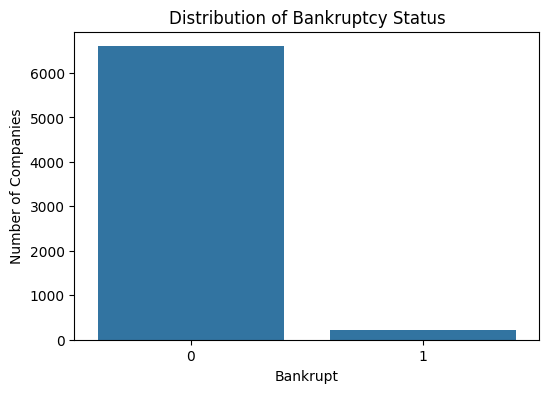

In [11]:
plt.figure(figsize=(6,4))

sns.countplot(x="Bankrupt?", data=df)

plt.title("Distribution of Bankruptcy Status")
plt.xlabel("Bankrupt")
plt.ylabel("Number of Companies")

plt.show()

The dataset is highly imbalanced, with only a small proportion of companies classified as bankrupt. This suggests that accuracy alone may not be a reliable metric when evaluating machine learning models later in the project.

In [12]:
df["Bankrupt?"].value_counts(normalize=True) * 100

,proportion
Bankrupt?,
0,96.77372
1,3.22628


In [13]:
correlations = df.corr()["Bankrupt?"].sort_values(ascending=False)

correlations.head(10)

,Bankrupt?
Bankrupt?,1.000000
Debt ratio %,0.250161
Current Liability to Assets,0.194494
Borrowing dependency,0.176543
Current Liability to Current Assets,0.171306
Liability to Equity,0.166812
Current Liabilities/Equity,0.153828
Current Liability to Equity,0.153828
Liability-Assets Flag,0.139212
Total expense/Assets,0.139049


In [14]:
correlations.tail(10)

,Bankrupt?
Per Share Net profit before tax (Yuan ¥),-0.201395
Net profit before tax/Paid-in capital,-0.207857
Retained Earnings to Total Assets,-0.217779
Persistent EPS in the Last Four Seasons,-0.219560
Net worth/Assets,-0.250161
ROA(C) before interest and depreciation before interest,-0.260807
ROA(B) before interest and depreciation after tax,-0.273051
ROA(A) before interest and % after tax,-0.282941
Net Income to Total Assets,-0.315457
Net Income Flag,NaN


Several financial indicators show stronger relationships with bankruptcy than others. These variables may be useful predictors and will be explored further during the modelling stage.

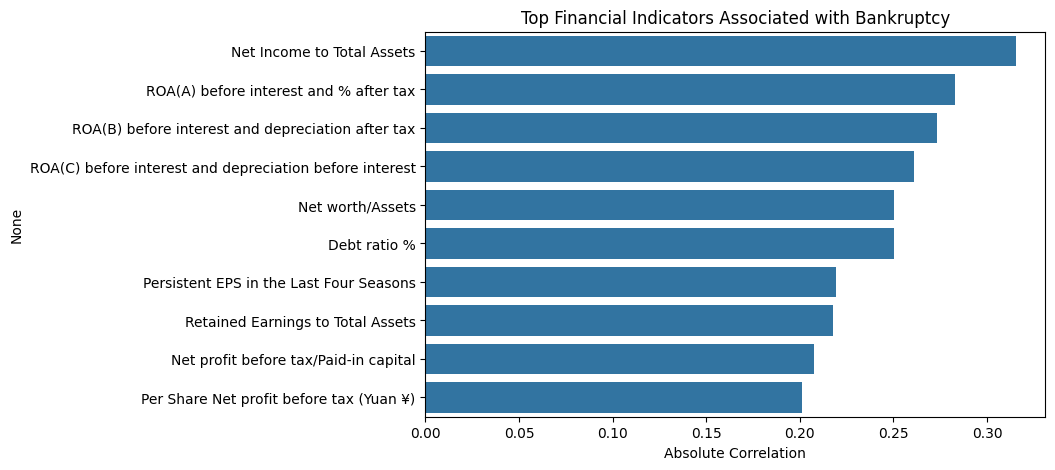

In [15]:
top_features = correlations.abs().sort_values(ascending=False)[1:11]

plt.figure(figsize=(8,5))

sns.barplot(
    x=top_features.values,
    y=top_features.index
)

plt.title("Top Financial Indicators Associated with Bankruptcy")
plt.xlabel("Absolute Correlation")
plt.savefig(
    "top_bankruptcy_features.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

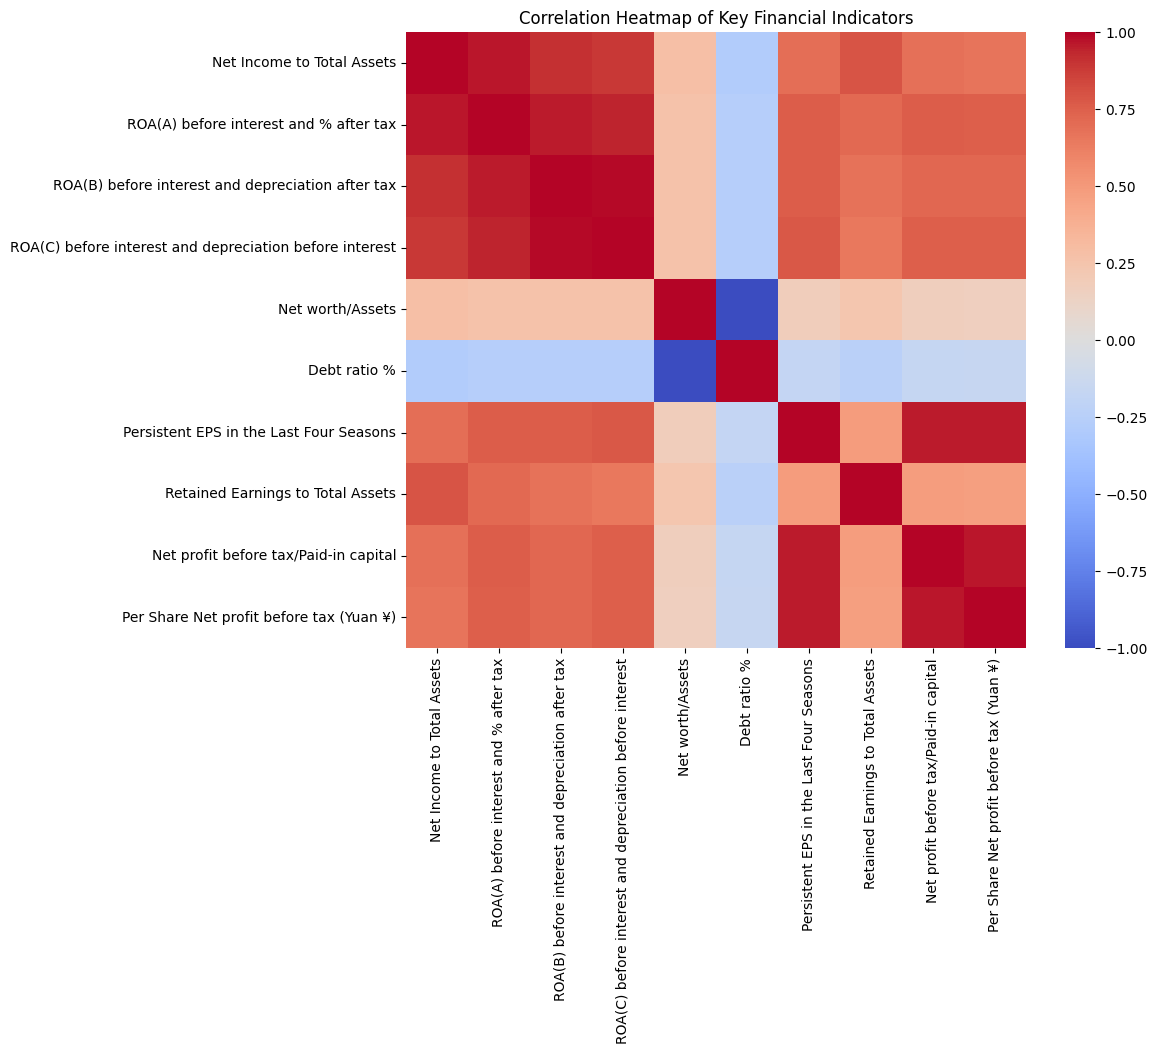

In [16]:
selected_features = top_features.index.tolist()

plt.figure(figsize=(10,8))

sns.heatmap(
    df[selected_features].corr(),
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Heatmap of Key Financial Indicators")
plt.savefig(
    "correlation_heatmap_financial_indicators.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



The heatmap illustrates the relationships between the most influential financial indicators. Although some variables are moderately correlated with one another, the selected features capture different aspects of a company's financial health, including profitability, liquidity and leverage.

In [17]:
df.columns.tolist()

['Bankrupt?',
 'ROA(C) before interest and depreciation before interest',
 'ROA(A) before interest and % after tax',
 'ROA(B) before interest and depreciation after tax',
 'Operating Gross Margin',
 'Realized Sales Gross Margin',
 'Operating Profit Rate',
 'Pre-tax net Interest Rate',
 'After-tax net Interest Rate',
 'Non-industry income and expenditure/revenue',
 'Continuous interest rate (after tax)',
 'Operating Expense Rate',
 'Research and development expense rate',
 'Cash flow rate',
 'Interest-bearing debt interest rate',
 'Tax rate (A)',
 'Net Value Per Share (B)',
 'Net Value Per Share (A)',
 'Net Value Per Share (C)',
 'Persistent EPS in the Last Four Seasons',
 'Cash Flow Per Share',
 'Revenue Per Share (Yuan ¥)',
 'Operating Profit Per Share (Yuan ¥)',
 'Per Share Net profit before tax (Yuan ¥)',
 'Realized Sales Gross Profit Growth Rate',
 'Operating Profit Growth Rate',
 'After-tax Net Profit Growth Rate',
 'Regular Net Profit Growth Rate',
 'Continuous Net Profit Growth 

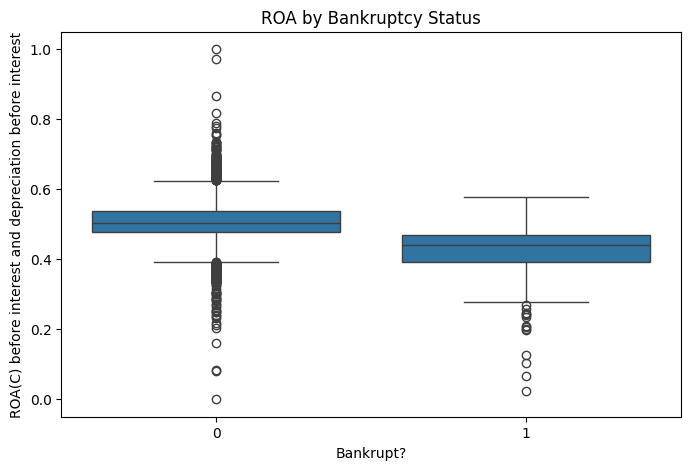

In [18]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Bankrupt?",
    y="ROA(C) before interest and depreciation before interest",
    data=df
)

plt.title("ROA by Bankruptcy Status")

plt.show()



Companies that went bankrupt generally showed lower profitability than non-bankrupt companies. This suggests that profitability may be an important indicator of financial distress and could play a significant role in predicting bankruptcy.

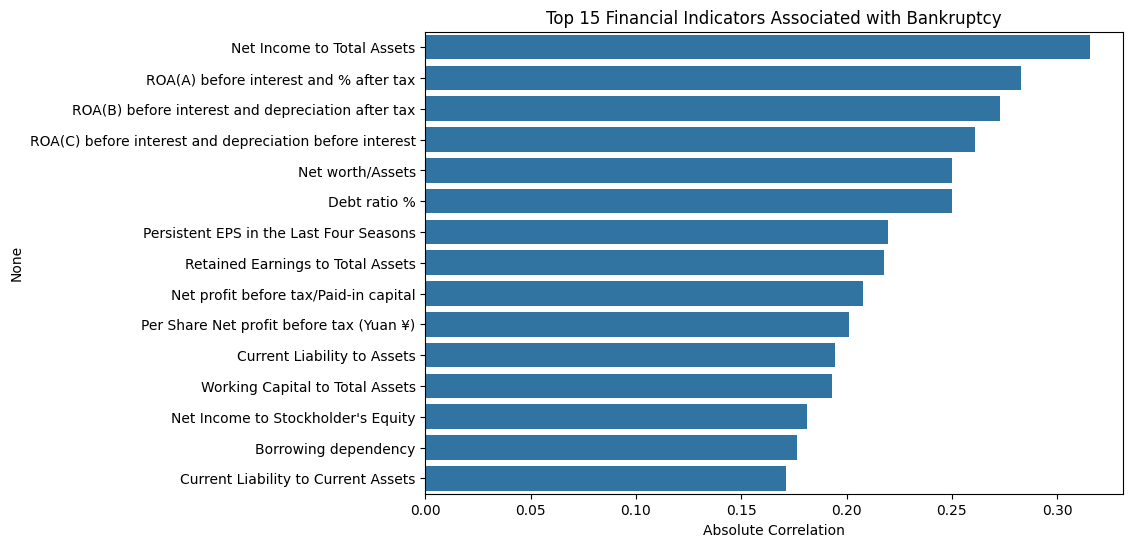

In [26]:
correlations = df.corr(numeric_only=True)["Bankrupt?"].sort_values()

top15 = correlations.abs().sort_values(ascending=False)[1:16]

plt.figure(figsize=(9,6))

sns.barplot(
    x=top15.values,
    y=top15.index
)

plt.title("Top 15 Financial Indicators Associated with Bankruptcy")
plt.xlabel("Absolute Correlation")

plt.savefig(
    "top15_features.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



The correlation analysis identified several financial ratios that were more strongly associated with bankruptcy than others. While correlation does not imply causation, these variables are likely to provide valuable information for the machine learning models and may contribute more to prediction accuracy.

## Summary of Exploratory Data Analysis

The exploratory analysis provided a better understanding of the financial characteristics of the companies in the dataset. The target variable was found to be highly imbalanced, with only a small proportion of companies classified as bankrupt, highlighting the importance of using evaluation metrics beyond accuracy.

The analysis also showed noticeable differences between bankrupt and non-bankrupt companies. Financial indicators related to profitability and debt appeared to have stronger relationships with bankruptcy, suggesting that these variables may play an important role in predicting financial distress.

Overall, the exploratory analysis helped identify the most relevant financial features and provided a solid foundation for the data preprocessing and model building stages.

## Data Preprocessing

Before training the models, the data was prepared by separating the target variable from the input features. The dataset was then split into training and testing sets, and feature scaling was applied where required.

In [29]:
X = df.drop("Bankrupt?", axis=1)
y = df["Bankrupt?"]

print("Feature matrix shape:", X.shape)
print("Target variable shape:", y.shape)

Feature matrix shape: (6819, 95)
Target variable shape: (6819,)


Train-Test Split

The dataset was divided into training and testing sets using an 80:20 split.

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (5455, 95)
Testing set: (1364, 95)


Feature Scaling

The financial ratios in the dataset have different ranges. Standardisation was applied so that each feature has a mean of 0 and a standard deviation of 1. This helps many machine learning algorithms perform more effectively.

In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

 Model Building

To evaluate which algorithm performs best for bankruptcy prediction,I trained four different classification models:
- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost

Using multiple models provides a more reliable comparison than relying on a single algorithm.

 Logistic Regression

Logistic Regression is a simple and widely used classification algorithm. It estimates the probability that a company belongs to the bankrupt or non-bankrupt class based on its financial indicators.

In [32]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

log_pred = log_model.predict(X_test_scaled)

 Decision Tree

A Decision Tree classifies companies by splitting the data into smaller groups based on financial ratios. The model is easy to interpret and can capture non-linear relationships.

In [35]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(random_state=42)

tree.fit(X_train, y_train)

tree_pred = tree.predict(X_test)

 Random Forest

Random Forest combines multiple decision trees to improve prediction accuracy and reduce overfitting. It is commonly used for classification problems involving structured financial data.

In [37]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

XGBoost

XGBoost is a gradient boosting algorithm that often achieves high performance on structured datasets. It builds trees sequentially, with each tree correcting errors made by the previous ones.

In [33]:
!pip install xgboost

In [38]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

Model Evaluation

After training the four classification models, their performance was evaluated using several metrics. Since the dataset is highly imbalanced, accuracy alone was not enough to assess model performance. Hence,I considered Precision, Recall, F1-score and ROC-AUC to provide a more complete evaluation.

In [39]:
models = {
    "Logistic Regression": (log_model, X_test_scaled, log_pred),
    "Decision Tree": (tree, X_test, tree_pred),
    "Random Forest": (rf, X_test, rf_pred),
    "XGBoost": (xgb, X_test, xgb_pred)
}

results = []

for name, (model, X_eval, predictions) in models.items():

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1 Score": f1_score(y_test, predictions),
        "ROC-AUC": roc_auc_score(y_test, model.predict_proba(X_eval)[:,1])
    })

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.961877,0.300000,0.136364,0.187500,0.852256
1,Decision Tree,0.960411,0.386364,0.386364,0.386364,0.682955
2,Random Forest,0.972141,0.800000,0.181818,0.296296,0.952264
3,XGBoost,0.968475,0.520000,0.295455,0.376812,0.960830


In [40]:
results_df = results_df.round(3)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.962,0.300,0.136,0.188,0.852
1,Decision Tree,0.960,0.386,0.386,0.386,0.683
2,Random Forest,0.972,0.800,0.182,0.296,0.952
3,XGBoost,0.968,0.520,0.295,0.377,0.961




All four models achieved high accuracy, largely due to the class imbalance in the dataset. However, accuracy alone does not provide a complete picture of performance. XGBoost achieved the highest ROC-AUC score (0.961), indicating the strongest ability to distinguish between bankrupt and non-bankrupt companies. Random Forest also performed well, while Logistic Regression and Decision Tree served as useful baseline models.

In [41]:
best_model = results_df.sort_values(
    by="ROC-AUC",
    ascending=False
)

best_model

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
3,XGBoost,0.968,0.520,0.295,0.377,0.961
2,Random Forest,0.972,0.800,0.182,0.296,0.952
0,Logistic Regression,0.962,0.300,0.136,0.188,0.852
1,Decision Tree,0.960,0.386,0.386,0.386,0.683


In [42]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99      1320
           1       0.80      0.18      0.30        44

    accuracy                           0.97      1364
   macro avg       0.89      0.59      0.64      1364
weighted avg       0.97      0.97      0.96      1364



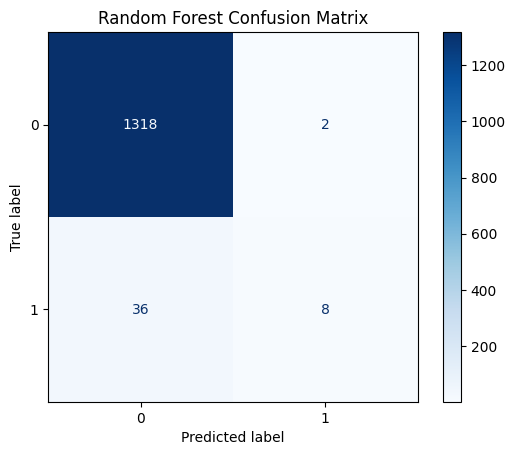

In [46]:
ConfusionMatrixDisplay.from_estimator(
    rf,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.savefig(
    "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



The confusion matrix shows that the model correctly classified the majority of non-bankrupt companies while identifying a portion of the bankrupt companies. Due to the imbalance in the dataset, predicting bankrupt companies remains more challenging, highlighting the importance of considering precision, recall and ROC-AUC alongside accuracy.

<Figure size 800x600 with 0 Axes>

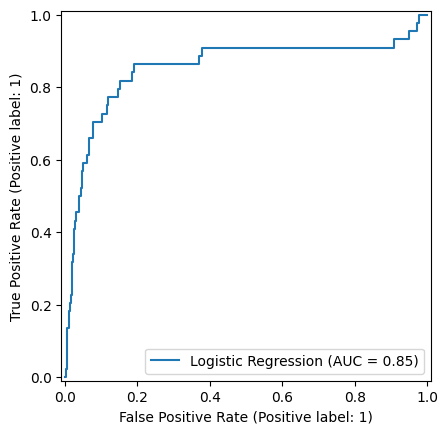

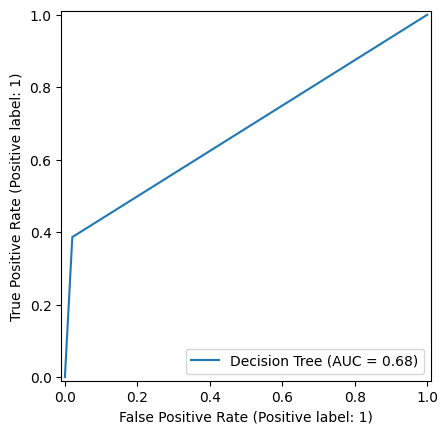

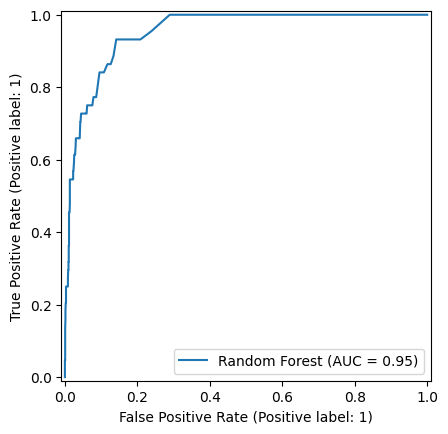

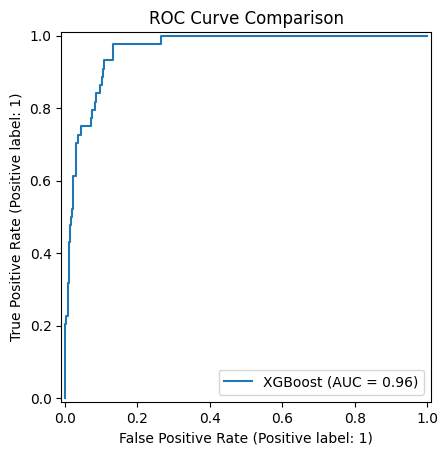

In [48]:
plt.figure(figsize=(8,6))

RocCurveDisplay.from_estimator(
    log_model,
    X_test_scaled,
    y_test,
    name="Logistic Regression"
)

RocCurveDisplay.from_estimator(
    tree,
    X_test,
    y_test,
    name="Decision Tree"
)

RocCurveDisplay.from_estimator(
    rf,
    X_test,
    y_test,
    name="Random Forest"
)

RocCurveDisplay.from_estimator(
    xgb,
    X_test,
    y_test,
    name="XGBoost"
)

plt.title("ROC Curve Comparison")
plt.savefig(
    "roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()



The ROC curve comparison shows that XGBoost and Random Forest consistently outperformed the other models, with XGBoost achieving the highest ROC-AUC score. This indicates that ensemble learning methods were better able to capture complex relationships within the financial data.

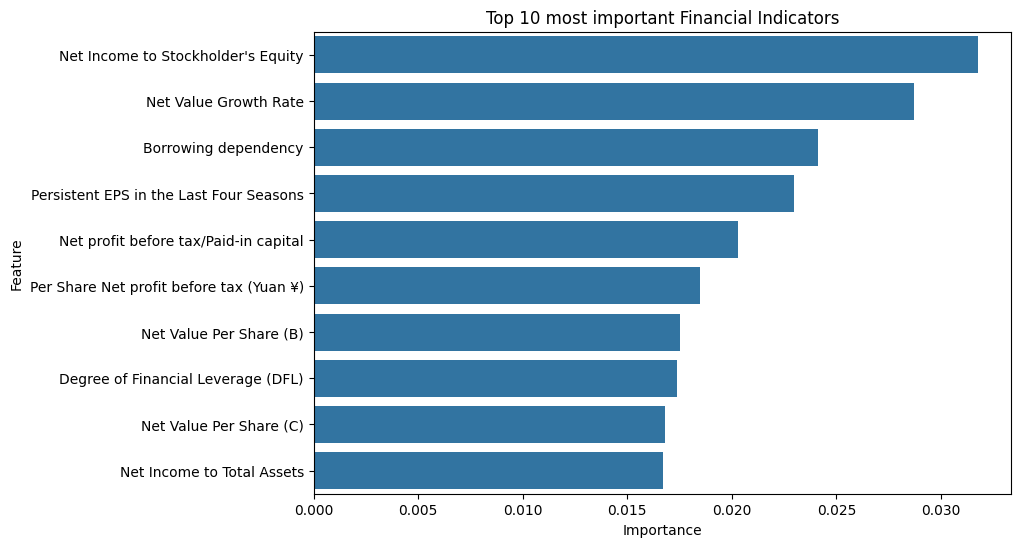

In [50]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)
top10 = feature_importance.head(10)

plt.figure(figsize=(9,6))

sns.barplot(
    data=top10,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 most important Financial Indicators")
plt.savefig(
    "feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



The feature importance analysis identified the financial indicators that contributed most to the Random Forest model's predictions. These variables appear to have the strongest influence on bankruptcy risk and provide valuable insights into the financial characteristics associated with corporate distress.

 Key Findings

- The dataset was highly imbalanced, making Precision, Recall and ROC-AUC more informative than accuracy.
- Profitability and debt-related financial indicators showed the strongest relationship with bankruptcy.
- XGBoost achieved the best overall performance with a ROC-AUC score of 0.961.
- Ensemble learning methods outperformed the simpler baseline models.

# Conclusion

This project explored the use of machine learning to predict corporate bankruptcy using financial statement data from Taiwanese companies. The workflow included data cleaning, exploratory data analysis, preprocessing, model training and performance evaluation.

Four classification models were compared: Logistic Regression, Decision Tree, Random Forest and XGBoost. Although all models achieved high accuracy, further evaluation showed that XGBoost delivered the strongest overall performance, achieving the highest ROC-AUC score of 0.961. Random Forest also performed well, particularly in terms of precision, demonstrating the effectiveness of ensemble learning methods for this problem.

The analysis also highlighted that financial indicators related to profitability and debt were among the most influential factors in predicting bankruptcy. These findings demonstrate how machine learning can support financial risk assessment by helping identify companies that may be at greater risk of financial distress.

Overall, this project strengthened my understanding of the complete machine learning workflow, from data exploration and preprocessing to model evaluation and interpretation, while demonstrating how predictive analytics can be applied to a real-world financial problem.